In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")
print(f"PyTorch: {torch.__version__}")

Устройство: cpu
PyTorch: 2.12.0+cpu


In [3]:
inputs_np = np.load("C:/Users/chuni/PycharmProjects/ProjectOlya/dataset0.5/inputs.npy")
targets_np = np.load("C:/Users/chuni/PycharmProjects/ProjectOlya/dataset0.5/targets.npy")

targets_np = targets_np.astype(np.float32)

In [4]:
print(inputs_np.shape, targets_np.shape)

(10000, 40, 40) (10000, 40, 40)


In [5]:
X = torch.from_numpy(inputs_np).unsqueeze(1).to(device)
y = torch.from_numpy(targets_np).unsqueeze(1).to(device)

In [6]:
#80% 20%

X_train, y_train = X[:8000], y[:8000]
X_val, y_val = X[8000:], y[8000:]

print(X.shape)
print(len(X_train), len(X_val))

torch.Size([10000, 1, 40, 40])
8000 2000


In [7]:
class GameOfLifeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1) # 16 фильтров -> 16 выходов
        self.conv2 = nn.Conv2d(16, 1, kernel_size=1) # 1 выход
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()  # 1 / (1 + e^(-x))


    def forward(self, x):
        x = self.conv1(x) # (batch, 1, 40, 40) -> (batch, 16, 40, 40)
        x = self.relu(x) # (batch, 16, 40, 40) -> (batch, 16, 40, 40)
        x = self.conv2(x) # (batch, 16, 40, 40) -> (batch, 1, 40, 40)
        x = self.sigmoid(x) # (batch, 1, 40, 40) -> (batch, 1, 40, 40)
        return x

In [8]:
model = GameOfLifeCNN().to(device)

In [9]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS     = 50
BATCH_SIZE = 64
train_losses, val_losses = [], []

print(f"{'Эпоха':>6}  {'Train Loss':>12}  {'Val Loss':>10}")
print("-" * 35)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss, n_batches = 0.0, 0

    for start in range(0, len(X_train), BATCH_SIZE):
        X_b = X_train[start : start + BATCH_SIZE]
        y_b = y_train[start : start + BATCH_SIZE]

        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    train_loss = epoch_loss / n_batches
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val), y_val).item()
    val_losses.append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        bar = '█' * int(20 * epoch / EPOCHS) + '░' * (20 - int(20 * epoch / EPOCHS))
        print(f"  {epoch:>4}  {train_loss:>12.6f}  {val_loss:>10.6f}  [{bar}]")

print(f"\nОшибка: {train_losses[0]:.4f} → {train_losses[-1]:.4f}")
print(f"Снижение на {(train_losses[0]-train_losses[-1])/train_losses[0]*100:.1f}%")

 Эпоха    Train Loss    Val Loss
-----------------------------------
     1      0.582953    0.509762  [░░░░░░░░░░░░░░░░░░░░]
    10      0.264122    0.249564  [████░░░░░░░░░░░░░░░░]
    20      0.165209    0.164211  [████████░░░░░░░░░░░░]
    30      0.154717    0.154564  [████████████░░░░░░░░]
    40      0.151248    0.151207  [████████████████░░░░]
    50      0.148502    0.148484  [████████████████████]

Ошибка: 0.5830 → 0.1485
Снижение на 74.5%


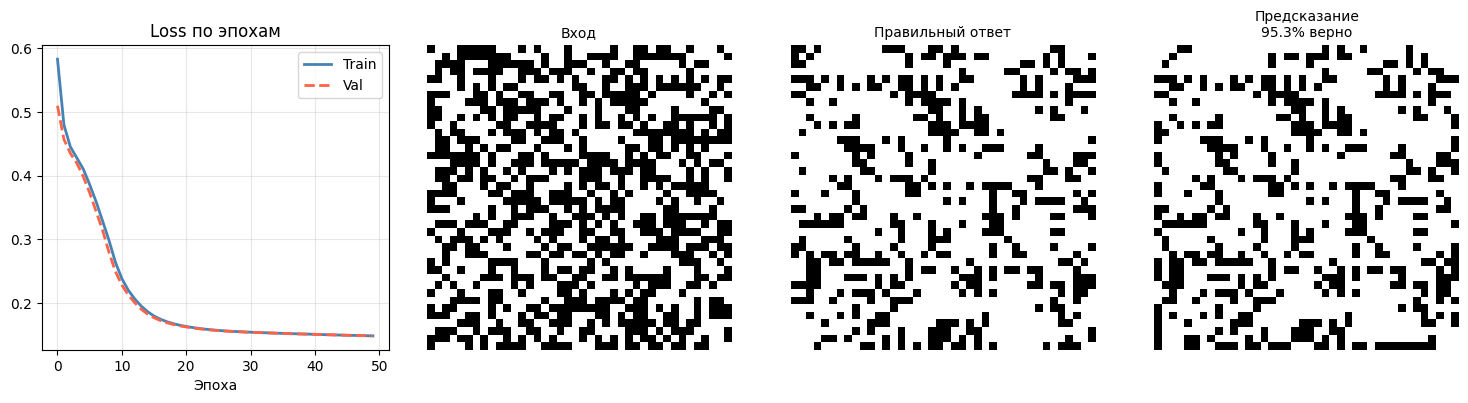

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].plot(train_losses, label='Train', linewidth=2, color='steelblue')
axes[0].plot(val_losses,   label='Val',   linewidth=2, color='tomato', linestyle='--')
axes[0].set_title('Loss по эпохам')
axes[0].set_xlabel('Эпоха')
axes[0].legend()
axes[0].grid(alpha=0.3)

model.eval()
with torch.no_grad():
    inp  = X_val[42:43]
    tgt  = y_val[42:43]
    pred = (model(inp) > 0.5).float()

accuracy = (pred[0,0].cpu().numpy() == tgt[0,0].cpu().numpy()).mean() * 100

for ax, data, title in [
    (axes[1], inp[0,0].cpu().numpy(),  'Вход'),
    (axes[2], tgt[0,0].cpu().numpy(),  'Правильный ответ'),
    (axes[3], pred[0,0].cpu().numpy(), f'Предсказание\n{accuracy:.1f}% верно'),
]:
    ax.imshow(data, cmap='binary', interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [12]:
class GameOfLifeCNN_circular(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1, padding_mode='circular') # 16 фильтров -> 16 выходов
        self.conv2 = nn.Conv2d(16, 1, kernel_size=1) # 1 выход
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()  # 1 / (1 + e^(-x))


    def forward(self, x):
        x = self.conv1(x) # (batch, 1, 40, 40) -> (batch, 16, 40, 40)
        x = self.relu(x) # (batch, 16, 40, 40) -> (batch, 16, 40, 40)
        x = self.conv2(x) # (batch, 16, 40, 40) -> (batch, 1, 40, 40)
        x = self.sigmoid(x) # (batch, 1, 40, 40) -> (batch, 1, 40, 40)
        return x

In [13]:
model_circular = GameOfLifeCNN_circular().to(device)

In [14]:
model_circular.load_state_dict(model.state_dict())

<All keys matched successfully>

In [15]:
model_circular.eval()
with torch.no_grad():
    preds_circ = (model_circular(X_val) > 0.5).float()

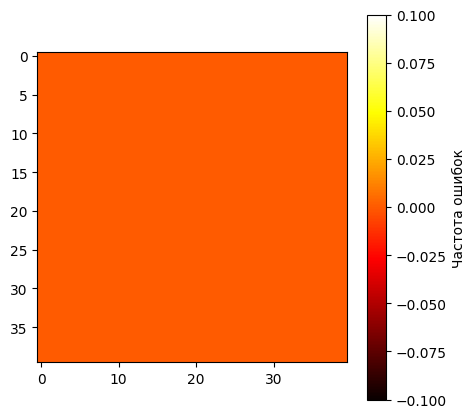

In [16]:
error_map = (preds_circ != y_val).float().mean(dim=0)[0].numpy()

plt.figure(figsize=(5,5))
plt.imshow(error_map, cmap='hot')
plt.colorbar(label='Частота ошибок')


In [17]:
model.eval() # выключает обучение
with torch.no_grad():
    preds = (model(X_val) > 0.5).float()

correct = (preds_circ == y_val)
print(correct.float().mean().item()*100) # средний процент правильных ответов

100.0


In [18]:
true_alive = (y_val == 1)
true_dead = (y_val == 0)
input_alive = (X_val == 1)


acc_birth = correct[(input_alive==0) & true_alive].float().mean().item()
acc_death = correct[(input_alive ==1) & true_dead].float().mean().item()
acc_survive = correct[(input_alive == 1) & true_alive].float().mean().item()
acc_stay_dead = correct[(input_alive == 0 ) & true_dead].float().mean().item()

In [19]:
print(acc_birth, acc_death, acc_survive, acc_stay_dead)

1.0 1.0 1.0 1.0


1. **Разную плотность данных (живая / неживая)**
2. Исследовать разную обработку краёв
3. **Другой клеточный автомат (High Life)**
4. Изменить датасет, увеличить врем до 5 поколений, 10 поколей, n поколений...

#### Визуализация фильтров

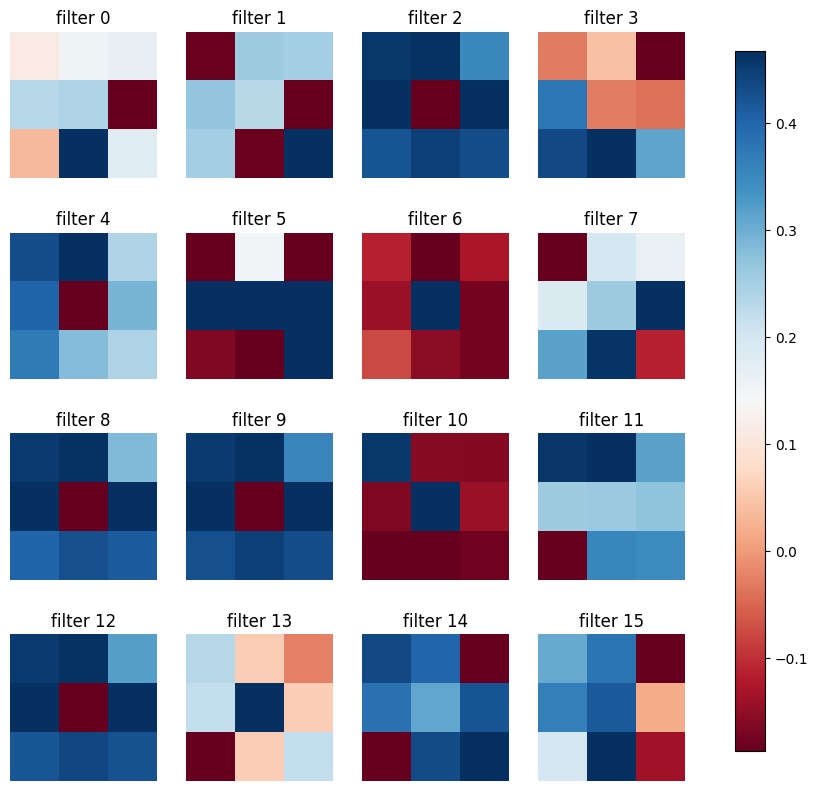

In [30]:
weights = model_circular.conv1.weight.detach().cpu().numpy()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i in range(16):
    ax = axes[i // 4, i % 4]
    filter_img = weights[i, 0, :, :]

    im = ax.imshow(filter_img, cmap='RdBu', interpolation='none')
    ax.set_title(f'filter {i}')
    ax.axis('off')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7])
fig.colorbar(im, cax=cbar_ax)

plt.show()

2, 8, 9, 12 - счётчики соседей
6, 10 - проверяют текущее состояние клетки
1, 3, 5, 7, 13, 15 - специфические паттерны
0, 4, 14 - угловые детекторы

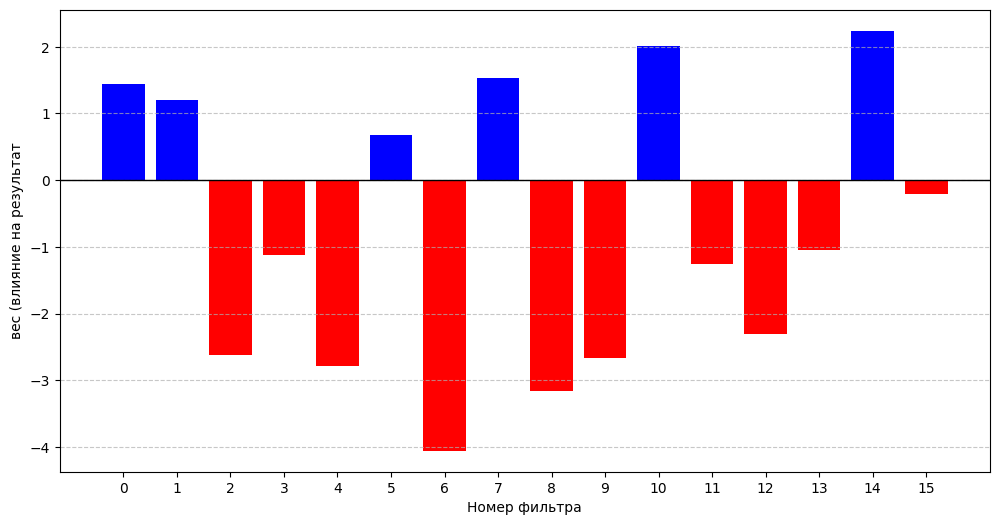

In [31]:
conv2_weights = model_circular.conv2.weight.detach().cpu().numpy().flatten()

plt.figure(figsize=(12,6))
colors = ['red' if w < 0 else 'blue' for w in conv2_weights]
plt.bar(range(16), conv2_weights, color=colors)

plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Номер фильтра')
plt.ylabel('вес (влияние на результат')
plt.xticks(range(16))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [32]:
for i, w in enumerate(conv2_weights):
    print(i, w)

0 1.4343346
1 1.2038281
2 -2.6160352
3 -1.1141632
4 -2.7778776
5 0.67979854
6 -4.0551653
7 1.5276929
8 -3.1610382
9 -2.66604
10 2.0120575
11 -1.2578087
12 -2.3068936
13 -1.0477632
14 2.240251
15 -0.20531525
